# EA Sports FC 26 player-attribute analysis

**Research question:** Which player attributes have the strongest relationship with an outfield player's overall rating in EA Sports FC 26?

Dataset source: [EAFC26 DataHub](https://github.com/ismailoksuz/EAFC26-DataHub), originally credited to the [FC 26 Player Data dataset on Kaggle](https://www.kaggle.com/datasets/rovnez/fc-26-fifa-26-player-data).

In [7]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/Fifa26_Arman"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Fifa26_Arman


In [8]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Keep analysis.py and the data folder beside this notebook.
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
import analysis

## 1. Load and clean the data
We remove duplicate player IDs, exclude goalkeepers because they use a different attribute system, and retain complete values for the selected outfield attributes.

In [9]:
df = analysis.load_and_clean()
print(f'Rows used: {len(df):,}')
display(df[['short_name', 'player_positions', 'overall', 'movement_reactions']].head())

Rows used: 16,343


,short_name,player_positions,overall,movement_reactions
0,J. Bellingham,"CAM, CM",90,91
1,F. Valverde,"CM, CDM, RB",89,89
2,J. Kimmich,"CDM, RB, CM",89,89
3,A. Hakimi,"RB, RM",89,90
4,N. Barella,CM,87,91


## 2. Pearson correlation analysis
Pearson's r measures the direction and strength of each linear relationship with overall rating. Values closer to 1 indicate a stronger positive relationship.

In [10]:
correlations, summary = analysis.analyse(df)
display(correlations.head(10).style.format({'pearson_r': '{:.3f}'}))
display(pd.Series(summary).to_frame('value'))

,attribute,pearson_r
0,movement_reactions,0.887
1,mentality_composure,0.822
2,attacking_short_passing,0.812
3,skill_ball_control,0.793
4,skill_long_passing,0.665
5,skill_dribbling,0.600
6,power_jumping,0.589
7,mentality_vision,0.576
8,power_shot_power,0.562
9,power_stamina,0.550


,value
raw_rows,18405.000000
analysis_rows,16343.000000
attribute_count,29.000000
overall_mean,65.961084
overall_median,66.000000
reaction_r,0.886838
reaction_r_squared,0.786482
slope,0.716862
intercept,21.244228


## 3. Visualisations

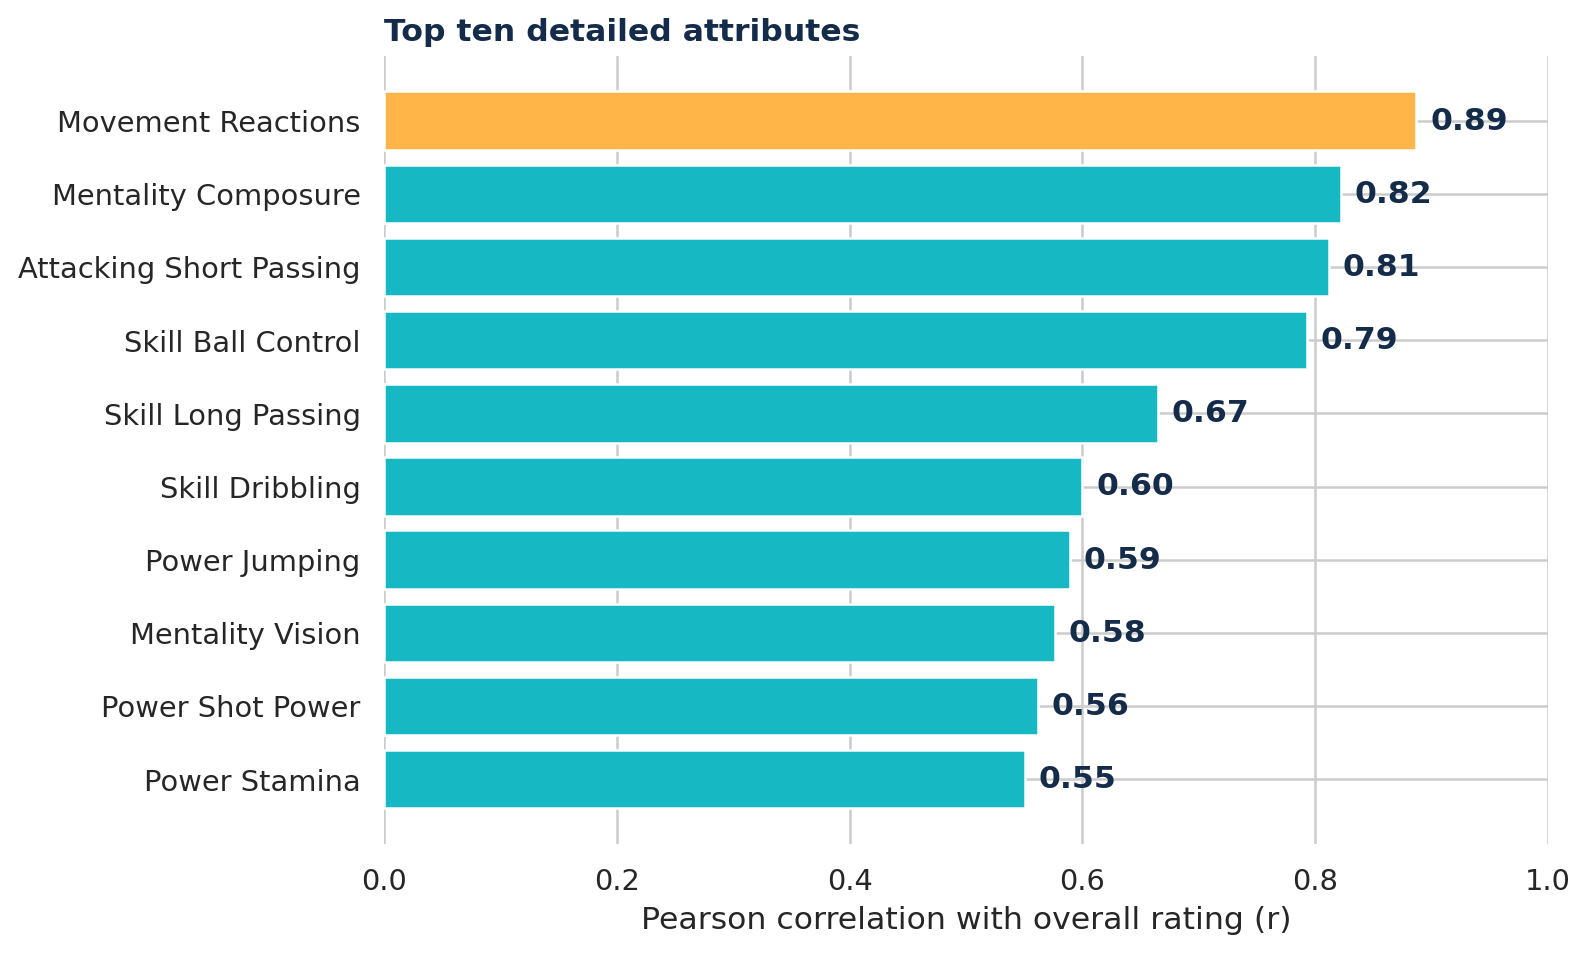

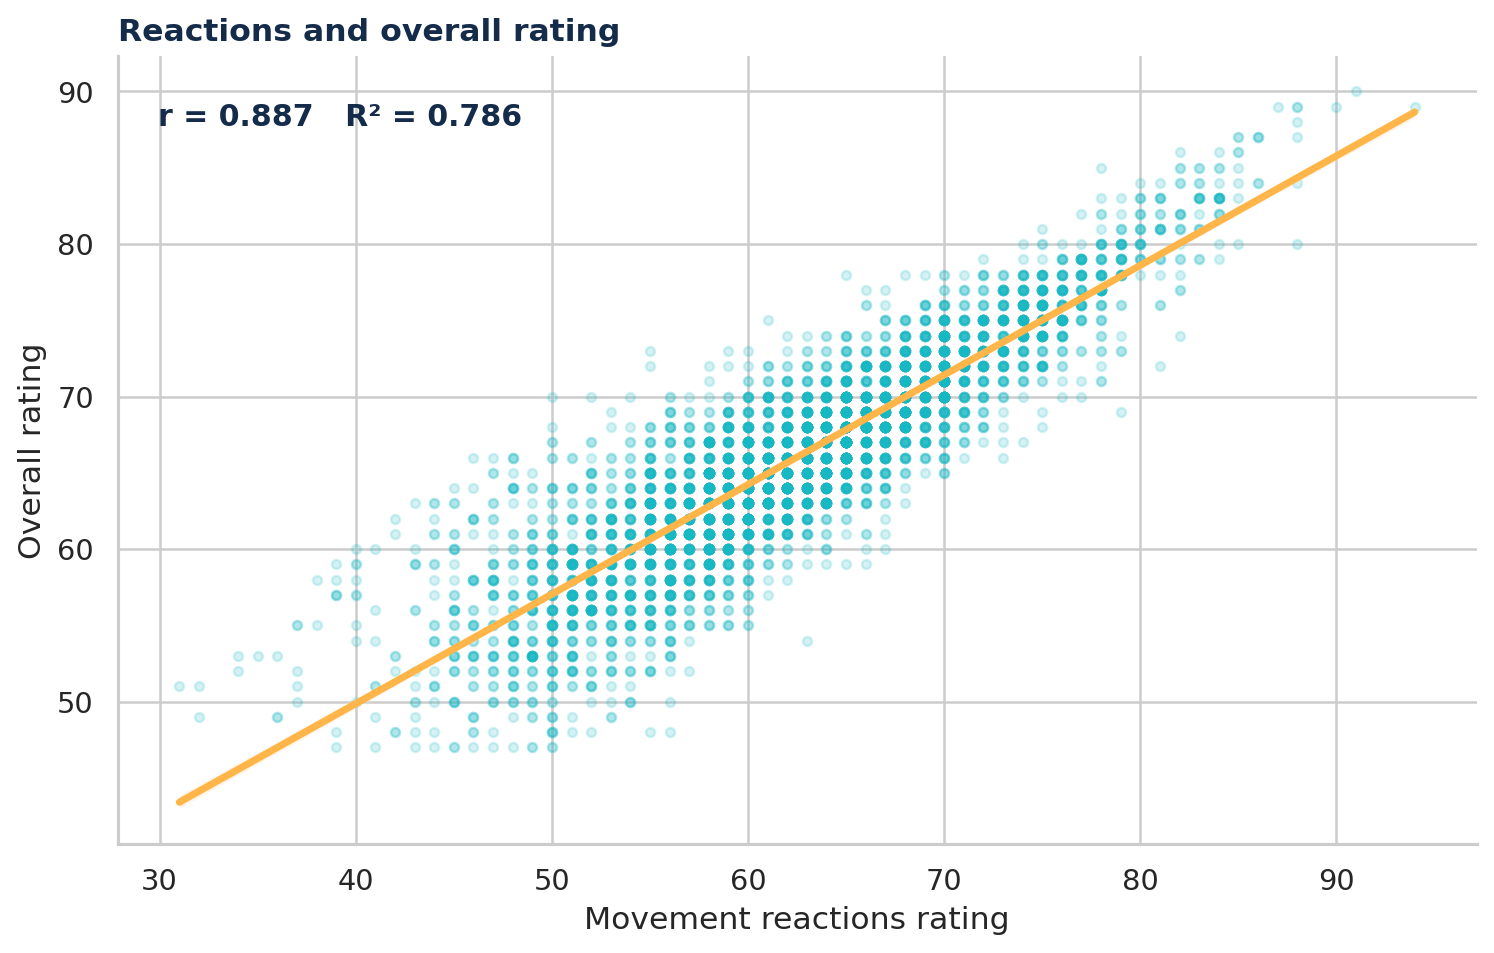

In [11]:
analysis.make_charts(df, correlations)
display(Image(filename='outputs/top_correlations.png'))
display(Image(filename='outputs/reactions_scatter.png'))

## 4. Conclusion and limitations
Movement reactions has the strongest relationship with overall rating (r = 0.887). Composure (0.822), short passing (0.812), and ball control (0.793) also show strong positive relationships. The simple reactions model has R² = 0.786. These findings describe association, not causation. EA may use these attributes when calculating overall ratings, and attribute importance can differ by playing position.